In [3]:
from ase.io import read, write
from fairchem.core.datasets.ase_datasets import AseDBDataset
from tqdm import tqdm
import os

In [9]:
dataset_path = '/u/czhang31/data/omol_sodium_elytes/aselmdb_data_20ormore/val'
a2g_args = {  
    "molecule_cell_size": 120.0,
    "r_energy": True,
    "r_forces": True,
    "r_stress": True,
}
dataset = AseDBDataset({
                        "src": dataset_path,
                        "a2g_args": a2g_args,
                        })

In [11]:
dataset[0].energy

tensor([-194361.7500])

Max length: 350
Min length: 3


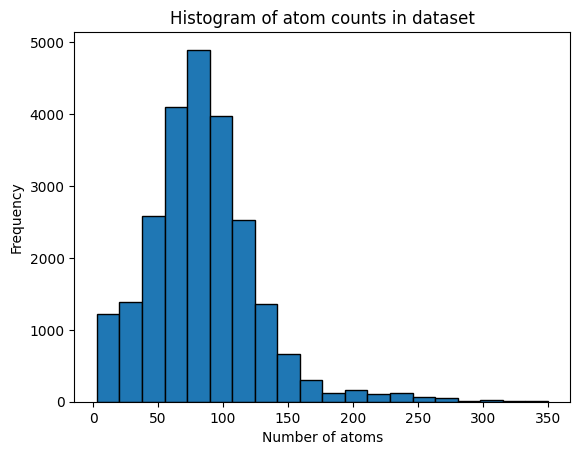

In [26]:
all_lengths = []
for i in range(len(dataset)):
    atoms = dataset.get_atoms(i)
    all_lengths.append(len(atoms))

print(f"Max length: {max(all_lengths)}")
print(f"Min length: {min(all_lengths)}")

import matplotlib.pyplot as plt

plt.hist(all_lengths, bins=20, edgecolor='black')
plt.xlabel('Number of atoms')
plt.ylabel('Frequency')
plt.title('Histogram of atom counts in dataset')
plt.show()

In [27]:
num_greater_than_20 = sum(1 for x in all_lengths if x >= 20)
print(f"Number of items in all_lengths greater than 20: {num_greater_than_20}")


Number of items in all_lengths greater than 20: 22671


In [12]:
len(all_lengths)

23732

## getting structures that are >=20 atoms

In [21]:
all_atoms = read('/u/czhang31/data/omol_sodium_elytes/train_xyz/sodium_elytes_train_4M.xyz', index=':')
print(len(all_atoms))
for atoms in all_atoms:
    if len(atoms) >= 20:
        write('/u/czhang31/data/omol_sodium_elytes/train_xyz/sodium_elytes_train_4M_20ormore.xyz', atoms, append=True)

13544


In [15]:
read_back = read('/u/czhang31/data/omol_sodium_elytes/train_xyz_20ormore/sodium_elytes_train_4M_20ormore.xyz', index=':')
print(len(read_back))

10087


In [25]:
count = 0
for atoms in read_back:
    if 'elytes' not in atoms.info['data_id']:
        print(atoms.info['data_id'])
        print()
        count += 1
print(count)

0


In [26]:
count = 0
for atoms in read_back:
    if 11 not in atoms.get_atomic_numbers():
        print(atoms)
        print()
        count += 1
print(count)

0


In [23]:
all_atoms = read('/u/czhang31/data/omol_sodium_elytes/val_xyz/sodium_elytes_val.xyz', index=':')
print(len(all_atoms))
for atoms in all_atoms:
    if len(atoms) >= 20:
        write('/u/czhang31/data/omol_sodium_elytes/val_xyz/sodium_elytes_val_20ormore.xyz', atoms, append=True)

23732


In [22]:
read_back = read('/u/czhang31/data/omol_sodium_elytes/val_xyz_20ormore/sodium_elytes_val_20ormore.xyz', index=':')
print(len(read_back))

22671


## need to write the 20ormore directly to lmdb

In [ ]:
import torch
from fairchem.core.datasets import AseDBDataset
import ase.db
from tqdm import tqdm

# Load sodium indices
sodium_indices = torch.load("/home/yuejian/project/MLFF-distill/sodium_elytes/elytes_sodium_id_list_train_4M.pt")
# Output aselmdb path
output_aselmdb = "/home/yuejian/project/MLFF-distill/OMOL/electrolytes_application/aselmdb_data/sodium_elytes_train_4M/sodium_elytes_train_4M.aselmdb"
# Load train_4M dataset
train_dataset_path = "/home/yuejian/project/MLFF-distill/OMOL/4M/train_4M"


# # Load sodium indices
# sodium_indices = torch.load("/home/yuejian/project/MLFF-distill/sodium_elytes/elytes_sodium_id_list_val.pt")
# # Output aselmdb path
# output_aselmdb = "/home/yuejian/project/MLFF-distill/OMOL/electrolytes_application/aselmdb_data/sodium_elytes_val/sodium_elytes_val.aselmdb"
# # Load train_4M dataset
# train_dataset_path = "/home/yuejian/project/MLFF-distill/OMOL/ALL/val"



a2g_args = {
    "molecule_cell_size": 120.0,
    "r_energy": True,
    "r_forces": True,
    "r_data_keys": [ 'spin','charge', "data_id"],
}
print("Loading train_4M dataset...")
dataset = AseDBDataset({
    "src": train_dataset_path,
    "a2g_args": a2g_args,
})

src_db = dataset.dbs
# Open/create destination aselmdb for writing
print(f"Writing sodium subset to {output_aselmdb} ...")
dst_db = ase.db.connect(output_aselmdb, use_lock_file=False)

for idx in tqdm(sodium_indices, desc="Dumping sodium entries"):
    atoms = dataset.get_atoms(idx)
    data = atoms.info
    if data["data_id"] == 'elytes' and 11 in dataset[idx]['atomic_numbers'] and len(atoms) >= 20:
        dst_db.write(atoms, data=data)

print("Done.")
dst_db.close()
src_db.close()

## testing reading every 10th traj frame

In [4]:
# xx_small_path = '/u/czhang31/MLFF-distill/APPLICATIONS/electrolytes/md_results/58_82_122k_models/natfsi_s1p1_distilled_82k_steps_md.traj'
xx_small_path = '/u/czhang31/MLFF-distill/APPLICATIONS/electrolytes/md_results/all_napf6_distill_DEG_md_65k.traj'
atoms_list = read(xx_small_path, index=":")
print(len(atoms_list))

1501


In [5]:
parent_dir = '/u/czhang31/data/1mnapf6_solvents_omol_trajs'
for path in sorted(os.listdir(parent_dir)):
    if path.endswith('.traj'):
        print(path)
        atoms_list = read(os.path.join(parent_dir, path), index=":")
        print(len(atoms_list))

md_omol_diethyleneglycol_pfactor_0.1_1fs_mask_t_re3_s1p1.traj
4716
md_omol_diglyme_pfactor_0.1_1fs_mask_t_re1_s1p1.traj
4409
md_omol_dimethylcarbonate_pfactor_0.1_1fs_mask_t_re3_s1p1.traj
6595
md_omol_napf6_tgdme_1m_s1p1.traj
2513
md_omol_propylene_carbonate_pfactor_0.1_1fs_mask_t_re1_s1p1.traj
4691
md_omol_tetrahydrofuran_pfactor_0.1_1fs_mask_t_re3_m1p1.traj
1551


In [6]:
og = read('/u/czhang31/data/napf6_s1p1/uma_traj/md_omol_re5_small_1p1_wrapped.traj', index=':')
len(og)

13667